In [ ]:
from rknnlite.api import RKNNLite
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

RKNN_MODEL = './Weight/yolo8s__3.rknn'
img_path = '/home/orangepi/Desktop/DetectPeople/Data/dataSet/Test/images/20_23.jpg'
# label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

# Инициализация RKNNLite
rknn_lite = RKNNLite()
ret = rknn_lite.load_rknn(RKNN_MODEL)
if ret != 0:
    print("Не удалось загрузить RKNN модель.")
    exit(1)

# Запуск рантайма на NPU (ядро 0)
ret = rknn_lite.init_runtime(core_mask=RKNNLite.NPU_CORE_0)
if ret != 0:
    print("Ошибка инициализации рантайма.")
    exit(1)

img = cv2.imread(img_path)
img = cv2.resize(img, (640, 640))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # ВАЖНО: RGB для модели
input_data = np.expand_dims(img.astype(np.uint8), axis=0)  # (1, 640, 640, 3)

outputs = rknn_lite.inference(inputs=[input_data])
print('Инференс завершён!')
# print('outputs:', outputs)

rknn_lite.release()

W Query dynamic range failed. Ret code: RKNN_ERR_MODEL_INVALID. (If it is a static shape RKNN model, please ignore the above warning message.)


I RKNN: [22:10:37.413] RKNN Runtime Information, librknnrt version: 1.6.0 (9a7b5d24c@2023-12-13T17:31:11)
I RKNN: [22:10:37.413] RKNN Driver Information, version: 0.9.3
I RKNN: [22:10:37.413] RKNN Model Information, version: 6, toolkit version: 2.3.2(compiler version: 2.3.2 (@2025-04-03T08:26:16)), target: RKNPU v2, target platform: rk3588, framework name: ONNX, framework layout: NCHW, model inference type: static_shape
W RKNN: [22:10:37.413] RKNN Model version: 2.3.2 not match with rknn runtime version: 1.6.0
W RKNN: [22:10:37.480] query RKNN_QUERY_INPUT_DYNAMIC_RANGE error, rknn model is static shape type, please export rknn with dynamic_shapes
Инференс завершён!


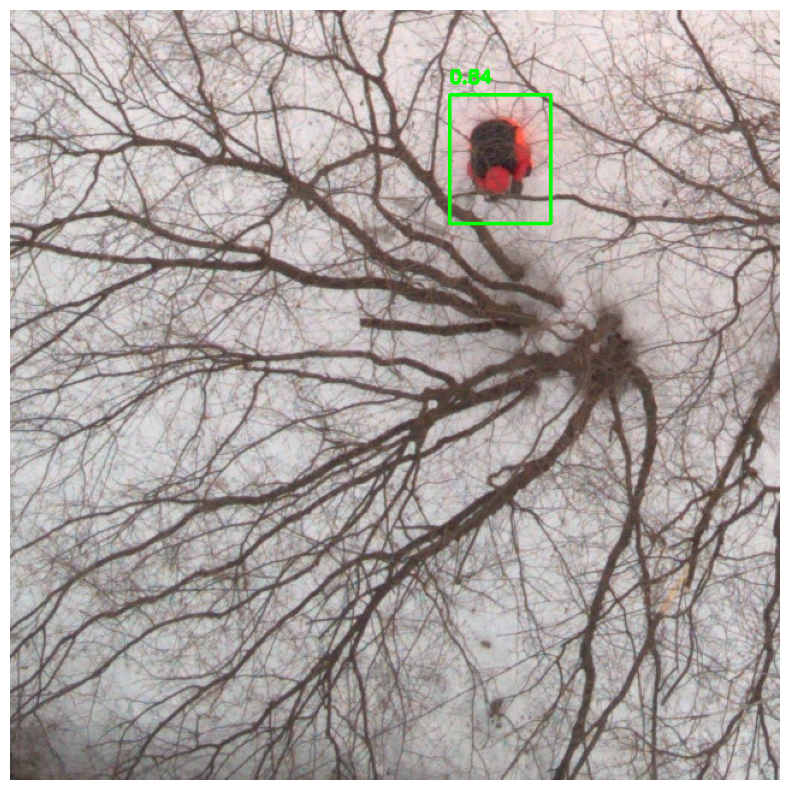

In [ ]:
orig_img = cv2.imread(img_path)  # Загружаем оригинал, без resize
h_orig, w_orig = orig_img.shape[:2]

data = outputs[0][0]  # (5, N)
boxes = data[:4, :].T
confidences = data[4, :]

conf_threshold = 0.3
mask = confidences > conf_threshold
boxes = boxes[mask]
confidences = confidences[mask]

# Масштабируем обратно
scale_x = w_orig / 640
scale_y = h_orig / 640
boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale_x
boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale_y

boxes = boxes.astype(np.int32)

indices = cv2.dnn.NMSBoxes(
    bboxes=boxes.tolist(),
    scores=confidences.tolist(),
    score_threshold=conf_threshold,
    nms_threshold=0.4
)

if len(indices) == 0:
    indices = []
else:
    indices = indices.flatten()

for i in indices:
    x_center, y_center, w, h = boxes[i]
    x1 = int((x_center - w / 2) * scale_x)
    y1 = int((y_center - h / 2) * scale_y)
    x2 = int((x_center + w / 2) * scale_x)
    y2 = int((y_center + h / 2) * scale_y)
    conf = confidences[i]
    cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig_img, f'{conf:.2f}', (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

rknn_lite.release()

[167 498 144 205] 0.87060547
[412 497  83 189] 0.86035156
[ 28 505  57 179] 0.8378906
[560 563  63 154] 0.828125


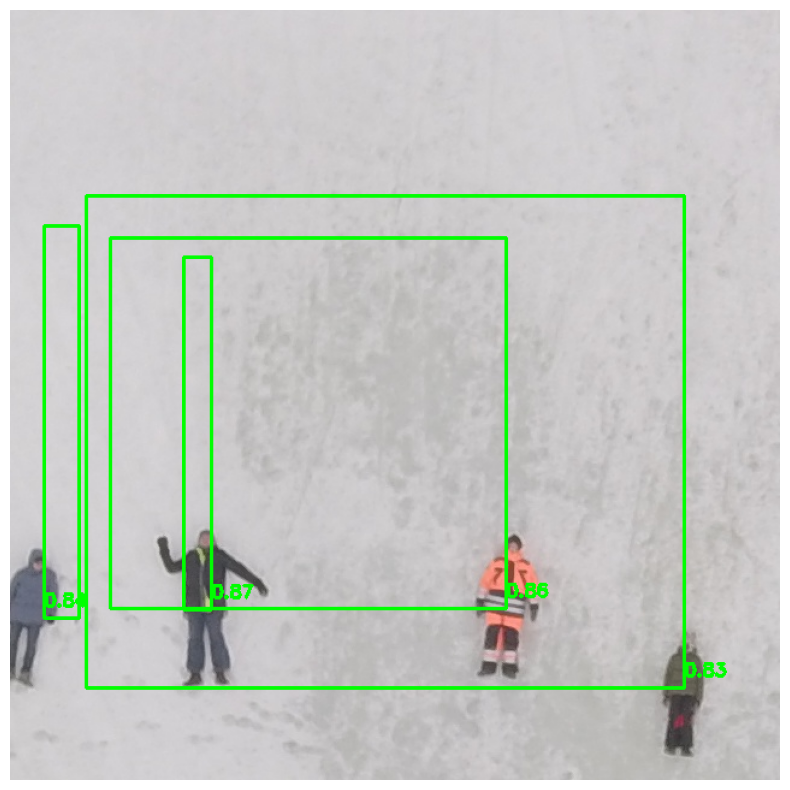

In [ ]:
# работает не корректно

orig_img = cv2.imread(img_path)  # Загружаем оригинал, без resize
h_orig, w_orig = orig_img.shape[:2]

data = outputs[0][0]  # (5, N)
boxes = data[:4, :].T
confidences = data[4, :]

conf_threshold = 0.3
mask = confidences > conf_threshold
boxes = boxes[mask]
confidences = confidences[mask]

# Масштабируем обратно
scale_x = w_orig / 640
scale_y = h_orig / 640
boxes[:, [0, 2]] = boxes[:, [0, 2]] * scale_x
boxes[:, [1, 3]] = boxes[:, [1, 3]] * scale_y

boxes = boxes.astype(np.int32)

indices = cv2.dnn.NMSBoxes(
    bboxes=boxes.tolist(),
    scores=confidences.tolist(),
    score_threshold=conf_threshold,
    nms_threshold=0.4
)

if len(indices) == 0:
    indices = []
else:
    indices = indices.flatten()

for i in indices:
    print(boxes[i], confidences[i])
    x1, y1, x2, y2 = boxes[i]
    conf = confidences[i]
    cv2.rectangle(orig_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(orig_img, f'{conf:.2f}', (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

rknn_lite.release()